## Analytical Velocity

$\
W_{\mathrm{c}} = \frac{2.07 \cdot Ek_c}{R_1} \cdot \mathrm{e}^{\,2.3026 \frac{x}{R_1}}
\
$

$
\text{AV}= Ek_{\text{pump}} + W_c
$

where $AV$ is in $ms^{-1}$ , $e$ is the Euler number and $x$ is the distance to the coast. 

In [2]:
ls '/gxfs_work/geomar/smomw662/NHCS/Processed/'

AV.jpg               Coastal_upwelling.mat  SST_SSH.mat
AV.mat               EKMAN_components.mat   WMLD_MLD.mat
AV_2.mat             Ekman_comp_SI.mat      WMLD_MLD_cal.mat
BEUTI.mat            Ekman_pump.mat         W_perfil_5_16.mat
BUI.jpg              Ekman_pump_2.mat       new_winds.mat
BUI.mat              HUI_index.mat          noEKMAN_components.mat
BUI.nc               HUI_index_2.mat        old_winds.mat
CUI_SST_index.mat    HUI_index_3.mat        rossby_radious_INPAINT.mat
CUTI.mat             MLD30km.kml            x.mat
CUTI_components.mat  Nitrogen.mat


In [3]:
from scipy.io import loadmat
import xarray as xr
import pandas as pd
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 
import math

In [4]:
ds = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [5]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [6]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [7]:
R = loadmat("/gxfs_work/geomar/smomw662/NHCS/Processed/rossby_radious_INPAINT.mat")
R
time = pd.date_range(start='1980-01', end='2016-01', freq='M')

/tmp/ipykernel_400196/2326092533.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [8]:
X = loadmat("/gxfs_work/geomar/smomw662/NHCS/Processed/x.mat")
X

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Dec 15 01:50:47 2025',
 '__version__': '1.0',
 '__globals__': [],
 'x': array([[3937.39978027, 3941.87268066, 3946.34924316, ..., 1742.80664062,
         1735.28877304, 1727.64535522],
        [3931.33349609, 3935.80639648, 3940.28295898, ..., 1738.14025879,
         1730.25866699, 1722.3789978 ],
        [3924.66662598, 3929.13952637, 3933.61608887, ..., 1733.47344971,
         1725.59185791, 1717.71218872],
        ...,
        [ 242.06671143,  241.91761702,  241.83169711, ...,  129.90563965,
          123.4993058 ,  117.30078888],
        [ 249.80029297,  249.80029297,  249.80029297, ...,  123.50543213,
          117.17994644,  110.82363371],
        [ 257.79980469,  257.76253962,  257.74106456, ...,  116.90919311,
          110.86325012,  104.41030791]])}

In [47]:
R_ds = xr.Dataset(
    data_vars={
        'R': (("lat","lon"), R['R2'].transpose(1, 0)),
        'X': (("lat","lon"), X['x'].transpose(1, 0)),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

R_ds = R_ds * inshore_mask *mask_nan * 1000 #in m
R_ds

<xarray.Dataset> Size: 5MB
Dimensions:  (lon: 602, lat: 542)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    R        (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan nan
    X        (lat, lon) float64 3MB nan nan nan nan nan ... nan nan nan nan nan

In [48]:
r = R_ds.sel(lat=slice(-16,-5)).R.mean(dim='lon')
r

x = R_ds.sel(lat=slice(-16,-5)).X.mean(dim='lon')
x

<xarray.DataArray 'X' (lat: 134)> Size: 1kB
array([ 87097.55478929,  82587.09673838,  85738.86638985,  81953.99055402,
        83772.57258475,  82785.60774408,  84865.46739154,  82081.56501521,
        81850.05347262,  78398.77117148,  74949.25507243,  71247.28744335,
        65237.49963602,  62471.57675424,  66542.26120986,  63374.41100988,
        62220.92236663,  65542.59103551,  66309.78963856,  65618.40514373,
        61900.5776344 ,  66154.49725153,  67995.02302644,  67026.59505208,
        71491.59622192,  79840.06769944,  79810.2125029 ,  80087.18154993,
        83414.79422294,  86020.83828463,  82839.58451573,  79001.20488656,
        81885.90148574,  81078.43937002,  77685.26518411,  78019.72771497,
        78308.68035675,  77319.71045248,  76181.16282729,  78324.03560559,
        80446.69636672,  75900.84989646,  77563.60892049,  75437.07842734,
        70832.98082436,  74455.78233562,  74714.06498051,  75764.98446986,
        80548.43699699,  77700.15886095,  77858.59439248,  81153.09972287,
        80725.05502847,  76071.29816078,  75317.57518507,  76687.06815535,
        77789.01338014,  81686.14795416,  78652.70905864,  75860.45302409,
        76546.15364498,  76186.46670857,  75155.15743766,  74058.18148661,
        72904.00032937,  68316.4148741 ,  70708.11260514,  73207.09486076,
        69622.18815105,  70151.43078292,  77044.55982242,  75665.8543431 ,
        78093.33304738,  75459.34022938,  80414.87336134,  80760.62788933,
        81022.43953417,  85575.21464988,  86111.54845517,  82467.24987418,
        83009.68212281,  86951.73690826,  87951.38915386,  92743.12683009,
        93806.47758998,  94657.13169449,  94357.58528583,  89603.61995364,
        86260.99957046,  83432.17559966,  77181.3371197 ,  70980.35657583,
        71550.48686372,  69873.74173896,  67880.29890645,  63183.20448042,
        61232.16059739,  63071.7829084 ,  73656.35725902,  85486.5088023 ,
        98229.68210164, 105342.17362918, 107177.29749896, 108591.50634049,
       106162.05962887, 101454.82693147, 101850.29454905,  99570.89772522,
        95452.13853448,  91540.58464223,  87256.97543658,  80655.010679  ,
        76173.04178003,  70877.16045308,  64384.17961582,  58675.34286555,
        52479.03406458,  48758.00991441,  45573.95832942,  45472.2655678 ,
        49039.86115644,  51511.23004515,  54884.7989169 ,  54884.7989169 ,
        56837.25533563,  58400.17424558,  61471.86182549,  66914.21508789,
        66591.42990577,  63671.5592247 ,  61747.23251693,  64052.64687723,
        63010.86877442,  61105.88610043])
Coordinates:
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076

In [49]:
Ek_c = xr.open_dataset('BUI/BUI_H.nc')
Ek_c = Ek_c.compute()
Ek_c

<xarray.Dataset> Size: 343MB
Dimensions:  (time: 317304, lat: 134)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    BUI      (time, lat) float64 340MB 1.78 1.823 1.903 ... 3.407 3.442 3.458

In [50]:
e =math.e
Wc = ((2.07 * Ek_c.BUI)/r)*e**(-2.3026*x/r)
Wc #m/s

<xarray.DataArray (time: 317304, lat: 134)> Size: 340MB
array([[1.47990075e-06, 1.84705920e-06, 1.70414953e-06, ...,
        1.61064849e-05, 1.59239850e-05, 1.56249041e-05],
       [1.47279789e-06, 1.84269730e-06, 1.69679285e-06, ...,
        1.78428039e-05, 1.75490772e-05, 1.71938126e-05],
       [1.47990075e-06, 1.84705920e-06, 1.70414953e-06, ...,
        1.61064849e-05, 1.59239850e-05, 1.56249041e-05],
       ...,
       [1.82303194e-06, 2.25901936e-06, 2.08337815e-06, ...,
        1.75466765e-05, 1.79600160e-05, 1.84818864e-05],
       [1.57388603e-06, 1.95372182e-06, 1.81320874e-06, ...,
        1.68448521e-05, 1.69665703e-05, 1.70438691e-05],
       [1.82303194e-06, 2.25901936e-06, 2.08337815e-06, ...,
        1.75466765e-05, 1.79600160e-05, 1.84818864e-05]])
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076

In [51]:
Pump = xr.open_dataset('Pump/Ekman_pumping_H.nc')/111e3
Pump = ((Pump.shift(lat=1) + Pump)*0.5).dropna('lat') #center to match the Wc lat 
Pump['lat'] = Wc.lat
Pump

<xarray.Dataset> Size: 343MB
Dimensions:  (time: 317304, lat: 134)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    w_ek     (time, lat) float64 340MB 2.693e-07 4.245e-08 ... 1.915e-06

In [54]:
AV = (Pump + Wc)*111e3
AV = AV['w_ek'].rename('AV')
AV

<xarray.DataArray 'AV' (time: 317304, lat: 134)> Size: 340MB
array([[0.19416607, 0.2097352 , 0.20781396, ..., 0.92988747, 1.86661771,
        2.9097966 ],
       [0.16394032, 0.15987184, 0.14652872, ..., 1.08721742, 1.83346028,
        2.71137401],
       [0.19416607, 0.2097352 , 0.20781396, ..., 0.92988747, 1.86661771,
        2.9097966 ],
       ...,
       [0.38919127, 0.40478437, 0.36309102, ..., 1.50988716, 1.79291708,
        2.26404008],
       [0.34804259, 0.376153  , 0.36203359, ..., 1.47666563, 2.04336142,
        2.64902341],
       [0.38919127, 0.40478437, 0.36309102, ..., 1.50988716, 1.79291708,
        2.26404008]])
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2016...
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076

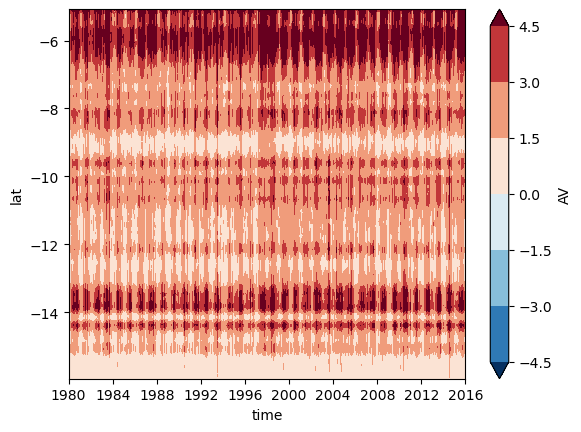

In [55]:
AV.plot.contourf(x='time',robust=True)